07 — Final Analysis: Toronto Climate Change & Snowfall
This notebook consolidates the historical analysis from Part A into one reproducible, portfolio-ready report.
Main questions
1. How much has Toronto warmed since the mid-20th century?
2. Which seasons have warmed most?
3. Have temperature extremes changed?
4. Has annual precipitation changed?
5. Has seasonal snowfall changed?
6. Is there evidence that warming accelerated?
Core datasets
- ECCC AHCCD daily temperature — Toronto City Centre
- ECCC CanHomP V2 homogenized precipitation
- ECCC Adjusted Daily Rainfall and Snowfall — Toronto long-term station series
Primary comparison period for temperature and precipitation: 1954–2023
Snowfall trend period: usable complete snow seasons only

In [1]:

from pathlib import Path
import calendar
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
import statsmodels.api as sm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Resolve project root whether notebook is run from project root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis


# 1. Load and validate AHCCD temperature data

In [2]:

TEMP_PATH = DATA_DIR / "raw" / "ahccd" / "ahccd.csv"

if not TEMP_PATH.exists():
    matches = list(PROJECT_ROOT.rglob("ahccd.csv"))
    if not matches:
        raise FileNotFoundError("Could not find ahccd.csv")
    TEMP_PATH = matches[0]

temp = pd.read_csv(TEMP_PATH)
temp["time"] = pd.to_datetime(temp["time"])
temp["year"] = temp["time"].dt.year
temp["month"] = temp["time"].dt.month

print("Shape:", temp.shape)
print("Date range:", temp["time"].min(), "→", temp["time"].max())
print("Station(s):", temp["station_name"].dropna().unique())
display(temp.head())


Shape: (25809, 15)
Date range: 1953-05-04 00:00:00 → 2023-12-31 00:00:00
Station(s): <ArrowStringArray>
['TORONTO CITY CENTRE']
Length: 1, dtype: str


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag,year,month
0,1953-05-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.5,NaN,14.4,NaN,10.6,NaN,1953,5
1,1953-05-05,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,11.4,NaN,15.6,NaN,7.2,NaN,1953,5
2,1953-05-06,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.3,NaN,16.7,NaN,7.8,NaN,1953,5
3,1953-05-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.3,NaN,18.3,NaN,8.3,NaN,1953,5
4,1953-05-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.8,NaN,17.2,NaN,8.3,NaN,1953,5


In [3]:

# Annual completeness
temp_quality = (
    temp.groupby("year")
    .agg(
        tas_valid=("tas", "count"),
        tasmax_valid=("tasmax", "count"),
        tasmin_valid=("tasmin", "count")
    )
    .reset_index()
)

temp_quality["expected_days"] = temp_quality["year"].apply(
    lambda y: 366 if calendar.isleap(int(y)) else 365
)

for col in ["tas", "tasmax", "tasmin"]:
    temp_quality[f"{col}_coverage_pct"] = (
        temp_quality[f"{col}_valid"] / temp_quality["expected_days"] * 100
    )

temp_quality["usable_tas"] = temp_quality["tas_coverage_pct"] >= 90
temp_quality["usable_tasmax"] = temp_quality["tasmax_coverage_pct"] >= 90
temp_quality["usable_tasmin"] = temp_quality["tasmin_coverage_pct"] >= 90

display(temp_quality.head())


,year,tas_valid,tasmax_valid,tasmin_valid,expected_days,tas_coverage_pct,tasmax_coverage_pct,tasmin_coverage_pct,usable_tas,usable_tasmax,usable_tasmin
0,1953,237,237,237,365,64.931507,64.931507,64.931507,False,False,False
1,1954,360,360,360,365,98.630137,98.630137,98.630137,True,True,True
2,1955,359,360,359,365,98.356164,98.630137,98.356164,True,True,True
3,1956,361,362,361,366,98.633880,98.907104,98.633880,True,True,True
4,1957,365,365,365,365,100.000000,100.000000,100.000000,True,True,True


# 2. Annual temperature trend

In [4]:

annual_temp = (
    temp.groupby("year")
    .agg(
        annual_mean_temp=("tas", "mean"),
        annual_max_temp=("tasmax", "mean"),
        annual_min_temp=("tasmin", "mean")
    )
    .reset_index()
    .merge(
        temp_quality[
            ["year", "usable_tas", "usable_tasmax", "usable_tasmin"]
        ],
        on="year",
        how="left"
    )
)

annual_temp.loc[~annual_temp["usable_tas"], "annual_mean_temp"] = np.nan
annual_temp.loc[~annual_temp["usable_tasmax"], "annual_max_temp"] = np.nan
annual_temp.loc[~annual_temp["usable_tasmin"], "annual_min_temp"] = np.nan

# Main period
annual_temp = annual_temp[
    annual_temp["year"].between(1954, 2023)
].copy()

baseline = annual_temp.loc[
    annual_temp["year"].between(1991, 2020),
    "annual_mean_temp"
].mean()

annual_temp["anomaly"] = annual_temp["annual_mean_temp"] - baseline
annual_temp["rolling_30yr"] = (
    annual_temp["annual_mean_temp"]
    .rolling(window=30, min_periods=25)
    .mean()
)

mean_data = annual_temp.dropna(subset=["annual_mean_temp"])
mean_result = linregress(
    mean_data["year"],
    mean_data["annual_mean_temp"]
)

tmax_data = annual_temp.dropna(subset=["annual_max_temp"])
tmax_result = linregress(
    tmax_data["year"],
    tmax_data["annual_max_temp"]
)

tmin_data = annual_temp.dropna(subset=["annual_min_temp"])
tmin_result = linregress(
    tmin_data["year"],
    tmin_data["annual_min_temp"]
)

print(f"1991–2020 baseline: {baseline:.3f} °C")
print(f"Mean temperature trend: {mean_result.slope*10:.3f} °C/decade")
print(f"p-value: {mean_result.pvalue:.3g}")
print(f"R²: {mean_result.rvalue**2:.3f}")
print(f"Tmax trend: {tmax_result.slope*10:.3f} °C/decade")
print(f"Tmin trend: {tmin_result.slope*10:.3f} °C/decade")


1991–2020 baseline: 8.849 °C
Mean temperature trend: 0.218 °C/decade
p-value: 1.52e-06
R²: 0.290
Tmax trend: 0.219 °C/decade
Tmin trend: 0.216 °C/decade


# Figure 1 — Annual mean temperature

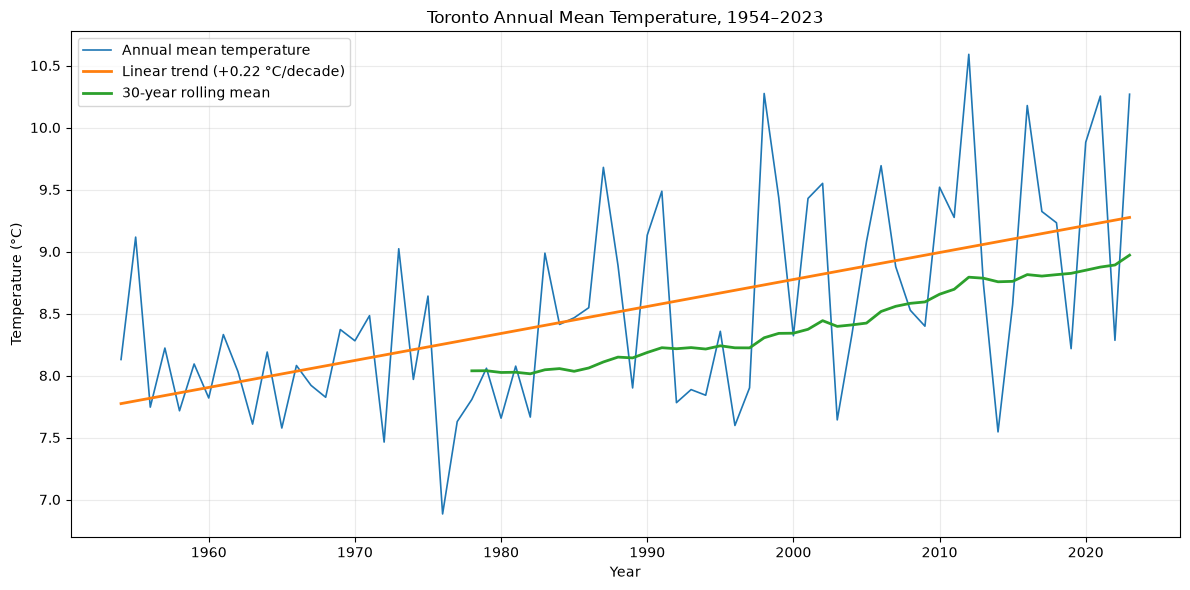

In [5]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    mean_data["year"],
    mean_data["annual_mean_temp"],
    linewidth=1.2,
    label="Annual mean temperature"
)

trend_line = mean_result.intercept + mean_result.slope * mean_data["year"]
ax.plot(
    mean_data["year"],
    trend_line,
    linewidth=2,
    label=f"Linear trend ({mean_result.slope*10:+.2f} °C/decade)"
)

ax.plot(
    annual_temp["year"],
    annual_temp["rolling_30yr"],
    linewidth=2,
    label="30-year rolling mean"
)

ax.set_title("Toronto Annual Mean Temperature, 1954–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_01_annual_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 3. Seasonal warming

In [6]:

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
}

seasonal = temp[
    temp["time"].between("1954-01-01", "2023-12-31")
].copy()

seasonal["season"] = seasonal["month"].map(season_map)
seasonal["season_year"] = seasonal["year"]
seasonal.loc[
    seasonal["month"] == 12,
    "season_year"
] = seasonal.loc[seasonal["month"] == 12, "year"] + 1

seasonal_means = (
    seasonal.groupby(["season_year", "season"])
    .agg(
        mean_temp=("tas", "mean"),
        valid_days=("tas", "count")
    )
    .reset_index()
)

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_results = []

for season in season_order:
    d = seasonal_means[
        (seasonal_means["season"] == season)
        & seasonal_means["season_year"].between(1955 if season == "Winter" else 1954, 2023)
    ].dropna(subset=["mean_temp"])

    r = linregress(d["season_year"], d["mean_temp"])

    season_results.append({
        "season": season,
        "trend_c_per_decade": r.slope * 10,
        "p_value": r.pvalue,
        "r2": r.rvalue ** 2
    })

season_trends = pd.DataFrame(season_results)
display(season_trends)


,season,trend_c_per_decade,p_value,r2
0,Winter,0.327328,0.000806,0.155338
1,Spring,0.179109,0.006652,0.103356
2,Summer,0.280029,0.000007,0.258941
3,Fall,0.144906,0.011494,0.090280


# Figure 2 — Seasonal warming rates

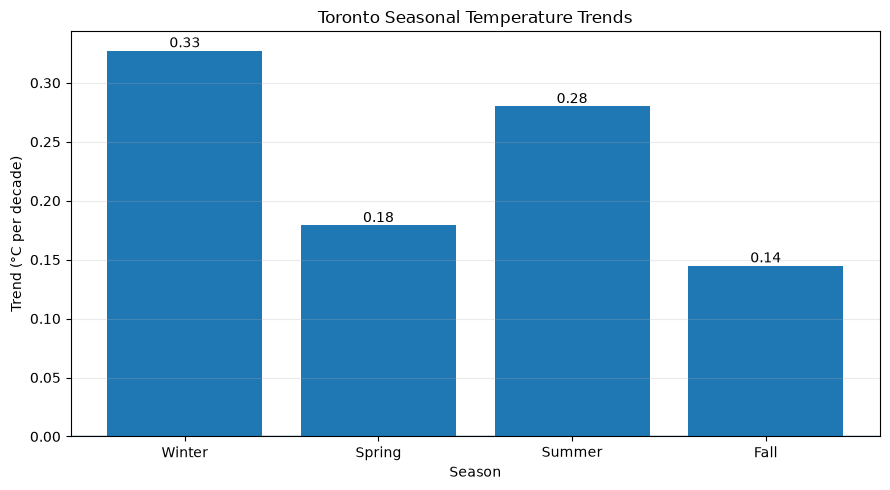

In [7]:

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    season_trends["season"],
    season_trends["trend_c_per_decade"]
)

ax.axhline(0, linewidth=1)
ax.set_title("Toronto Seasonal Temperature Trends")
ax.set_xlabel("Season")
ax.set_ylabel("Trend (°C per decade)")
ax.grid(axis="y", alpha=0.25)

for i, row in season_trends.iterrows():
    ax.text(
        i,
        row["trend_c_per_decade"],
        f'{row["trend_c_per_decade"]:.2f}',
        ha="center",
        va="bottom"
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "final_02_seasonal_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 4. Temperature extremes

In [8]:

# Fixed reference thresholds from the 1991–2020 climate-normal period
baseline_days = temp[
    temp["time"].between("1991-01-01", "2020-12-31")
]

hot_threshold = baseline_days["tasmax"].quantile(0.95)
cold_threshold = baseline_days["tasmin"].quantile(0.05)

extreme_daily = temp[
    temp["time"].between("1954-01-01", "2023-12-31")
].copy()

extreme_daily["extreme_hot"] = extreme_daily["tasmax"] >= hot_threshold
extreme_daily["extreme_cold"] = extreme_daily["tasmin"] <= cold_threshold

extreme_counts = (
    extreme_daily.groupby("year")
    .agg(
        extreme_hot_days=("extreme_hot", "sum"),
        extreme_cold_days=("extreme_cold", "sum")
    )
    .reset_index()
)

hot_result = linregress(
    extreme_counts["year"],
    extreme_counts["extreme_hot_days"]
)

cold_result = linregress(
    extreme_counts["year"],
    extreme_counts["extreme_cold_days"]
)

print(f"95th percentile Tmax threshold: {hot_threshold:.2f} °C")
print(f"5th percentile Tmin threshold: {cold_threshold:.2f} °C")
print(f"Extreme hot trend: {hot_result.slope*10:+.3f} days/decade, p={hot_result.pvalue:.4f}")
print(f"Extreme cold trend: {cold_result.slope*10:+.3f} days/decade, p={cold_result.pvalue:.4f}")


95th percentile Tmax threshold: 27.50 °C
5th percentile Tmin threshold: -11.10 °C
Extreme hot trend: +1.355 days/decade, p=0.0160
Extreme cold trend: -1.327 days/decade, p=0.0131


# Figure 3 — Extreme hot and cold days

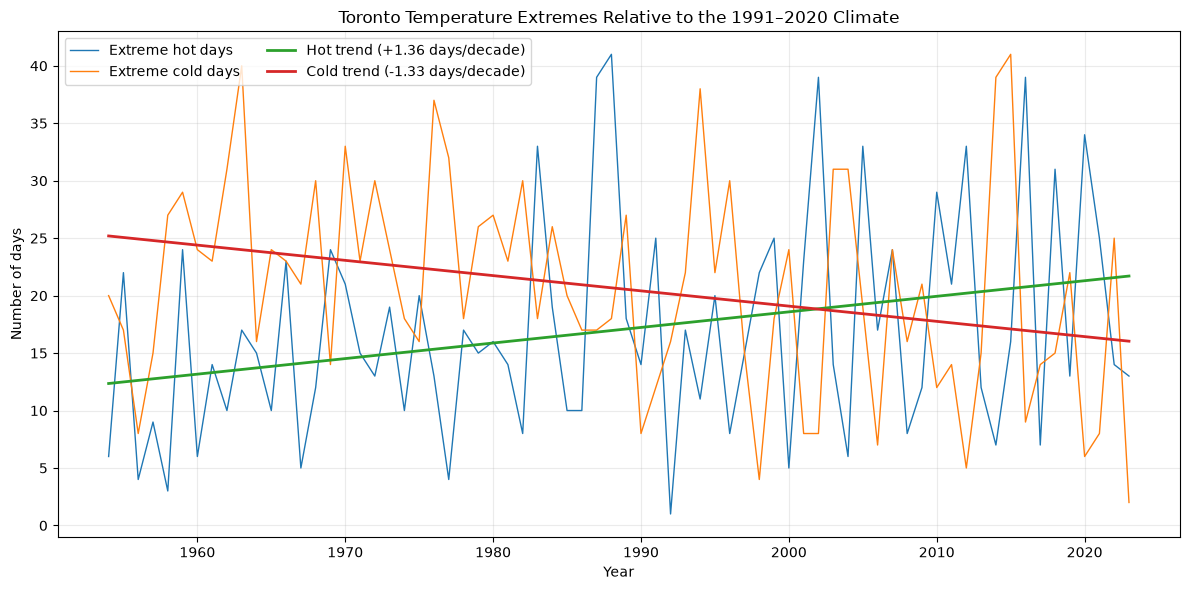

In [10]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    extreme_counts["year"],
    extreme_counts["extreme_hot_days"],
    linewidth=1,
    label="Extreme hot days"
)

ax.plot(
    extreme_counts["year"],
    extreme_counts["extreme_cold_days"],
    linewidth=1,
    label="Extreme cold days"
)

ax.plot(
    extreme_counts["year"],
    hot_result.intercept + hot_result.slope * extreme_counts["year"],
    linewidth=2,
    label=f"Hot trend ({hot_result.slope*10:+.2f} days/decade)"
)

ax.plot(
    extreme_counts["year"],
    cold_result.intercept + cold_result.slope * extreme_counts["year"],
    linewidth=2,
    label=f"Cold trend ({cold_result.slope*10:+.2f} days/decade)"
)

ax.set_title("Toronto Temperature Extremes Relative to the 1991–2020 Climate")
ax.set_xlabel("Year")
ax.set_ylabel("Number of days")
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_03_temperature_extremes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Change-point / acceleration check

In [11]:

cp_data = annual_temp.dropna(subset=["annual_mean_temp"]).copy()
cp_data["year_c"] = cp_data["year"] - cp_data["year"].min()

models = []

for break_year in range(1970, 2001):
    x = cp_data["year"] - break_year
    cp_data["post_break"] = np.where(x > 0, x, 0)

    X = sm.add_constant(cp_data[["year_c", "post_break"]])
    model = sm.OLS(cp_data["annual_mean_temp"], X).fit()

    models.append({
        "break_year": break_year,
        "aic": model.aic,
        "bic": model.bic,
        "before_slope": model.params["year_c"],
        "slope_change": model.params["post_break"],
        "slope_change_p": model.pvalues["post_break"],
        "after_slope": model.params["year_c"] + model.params["post_break"]
    })

break_scan = pd.DataFrame(models)
best_break = break_scan.loc[break_scan["aic"].idxmin()]

display(break_scan.nsmallest(5, "aic"))

print(f"Best candidate breakpoint by AIC: {int(best_break['break_year'])}")
print(f"Before slope: {best_break['before_slope']*10:+.3f} °C/decade")
print(f"After slope: {best_break['after_slope']*10:+.3f} °C/decade")
print(f"Slope-change p-value: {best_break['slope_change_p']:.4f}")


,break_year,aic,bic,before_slope,slope_change,slope_change_p,after_slope
6,1976,148.995962,155.741447,-0.005356,0.035845,0.076718,0.030488
7,1977,149.029936,155.775422,-0.003683,0.034495,0.078253,0.030812
8,1978,149.140746,155.886232,-0.001884,0.032919,0.083494,0.031034
5,1975,149.165696,155.911182,-0.006330,0.036246,0.084725,0.029917
4,1974,149.261505,156.006991,-0.007729,0.037187,0.089641,0.029459


Best candidate breakpoint by AIC: 1976
Before slope: -0.054 °C/decade
After slope: +0.305 °C/decade
Slope-change p-value: 0.0767


# Interpretation rule: the breakpoint with the lowest AIC is the best-fitting candidate among the tested segmented models, 
# but a breakpoint should not be described as a statistically significant acceleration unless the slope-change term itself is significant.

# 6. Annual precipitation

In [12]:

# Find the Toronto CanHomP daily file.
precip_matches = list(PROJECT_ROOT.rglob("AdjTo_6158355_dly.txt"))

if not precip_matches:
    raise FileNotFoundError(
        "Could not find AdjTo_6158355_dly.txt under the project folder."
    )

PRECIP_PATH = precip_matches[0]

records = []

with open(PRECIP_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.lstrip().startswith("#"):
            continue

        nums = re.findall(r"-?\d+", line)

        # Expected numeric fields:
        # year, month, day, HomP, GFQCdP, AdjP, SourceClimID
        if len(nums) >= 7:
            year, month, day, homp, gfq, adjp, source = nums[:7]

            records.append({
                "year": int(year),
                "month": int(month),
                "day": int(day),
                "HomP": int(homp),
                "SourceClimID": int(source)
            })

precip = pd.DataFrame(records)

precip["HomP"] = precip["HomP"].replace(-9999, np.nan)
precip["precip_mm"] = precip["HomP"] / 10.0
precip["date"] = pd.to_datetime(
    precip[["year", "month", "day"]],
    errors="coerce"
)

precip = precip[
    precip["date"].between("1954-01-01", "2023-12-31")
].copy()

annual_precip = (
    precip.groupby("year")
    .agg(
        annual_precip_mm=("precip_mm", lambda x: x.sum(min_count=1)),
        valid_days=("precip_mm", "count")
    )
    .reset_index()
)

annual_precip["expected_days"] = annual_precip["year"].apply(
    lambda y: 366 if calendar.isleap(int(y)) else 365
)

annual_precip["coverage_pct"] = (
    annual_precip["valid_days"]
    / annual_precip["expected_days"]
    * 100
)

annual_precip.loc[
    annual_precip["coverage_pct"] < 90,
    "annual_precip_mm"
] = np.nan

precip_trend = annual_precip.dropna(subset=["annual_precip_mm"])

precip_result = linregress(
    precip_trend["year"],
    precip_trend["annual_precip_mm"]
)

print(f"Average annual precipitation: {precip_trend['annual_precip_mm'].mean():.1f} mm")
print(f"Trend: {precip_result.slope*10:+.2f} mm/decade")
print(f"p-value: {precip_result.pvalue:.4f}")
print(f"R²: {precip_result.rvalue**2:.3f}")


Average annual precipitation: 886.9 mm
Trend: -8.92 mm/decade
p-value: 0.2092
R²: 0.023


# Figure 4 — Annual precipitation

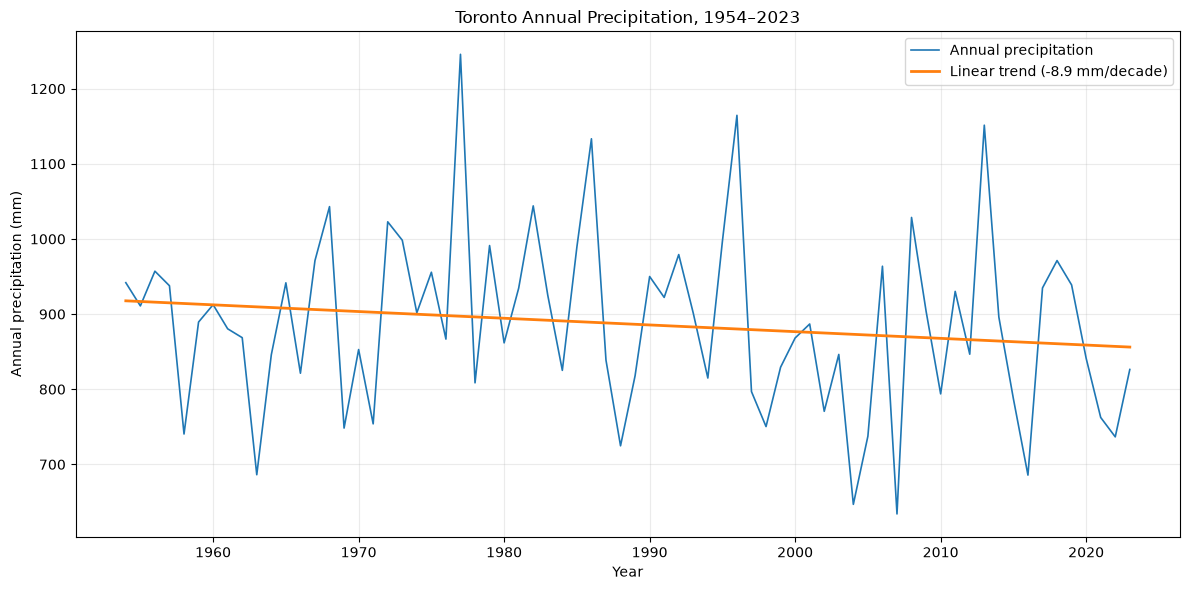

In [13]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    precip_trend["year"],
    precip_trend["annual_precip_mm"],
    linewidth=1.2,
    label="Annual precipitation"
)

ax.plot(
    precip_trend["year"],
    precip_result.intercept + precip_result.slope * precip_trend["year"],
    linewidth=2,
    label=f"Linear trend ({precip_result.slope*10:+.1f} mm/decade)"
)

ax.set_title("Toronto Annual Precipitation, 1954–2023")
ax.set_xlabel("Year")
ax.set_ylabel("Annual precipitation (mm)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_04_annual_precipitation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. Seasonal snowfall

In [14]:

snow_matches = list(PROJECT_ROOT.rglob("6158350_QCdRSP.txt"))

if not snow_matches:
    raise FileNotFoundError(
        "Could not find 6158350_QCdRSP.txt under the project folder."
    )

SNOW_PATH = snow_matches[0]

colspecs = [
    (0, 7), (8, 12), (12, 14), (14, 16),
    (18, 21), (23, 27),

    (28, 34), (34, 35),
    (36, 44), (44, 45),
    (46, 54), (54, 57),

    (58, 64), (64, 65),
    (66, 74), (74, 75),
    (76, 84), (84, 87),

    (88, 96), (96, 102),
    (103, 111), (111, 117)
]

columns = [
    "clim_id", "year", "month", "day",
    "source", "name",

    "rain_raw", "rain_raw_flag",
    "rain_c1_mm", "rain_c1_flag",
    "rain_corrected_mm", "rain_flags",

    "snow_raw", "snow_raw_flag",
    "snow_c1_mm", "snow_c1_flag",
    "snow_corrected_mm", "snow_flags",

    "precip_corrected_mm", "precip_flags",
    "precip_qc_mm", "precip_qc_flags"
]

snow = pd.read_fwf(
    SNOW_PATH,
    skiprows=1,
    colspecs=colspecs,
    names=columns
)

snow["date"] = pd.to_datetime(
    snow[["year", "month", "day"]],
    errors="coerce"
)

snow["snow_raw_clean"] = snow["snow_raw"].astype(float)
snow.loc[snow["snow_raw_clean"] < 0, "snow_raw_clean"] = np.nan
snow["snowfall_cm"] = snow["snow_raw_clean"] / 10.0

snow_analysis = snow[
    snow["date"].between("1954-07-01", "2016-06-30")
].copy()

snow_analysis["season_year"] = np.where(
    snow_analysis["month"] >= 7,
    snow_analysis["year"] + 1,
    snow_analysis["year"]
)

seasonal_snow = (
    snow_analysis.groupby("season_year")
    .agg(
        snowfall_cm=("snowfall_cm", lambda x: x.sum(min_count=1)),
        valid_days=("snowfall_cm", "count")
    )
    .reset_index()
)

def expected_snow_season_days(season_year):
    start = pd.Timestamp(int(season_year) - 1, 7, 1)
    end = pd.Timestamp(int(season_year), 6, 30)
    return (end - start).days + 1

seasonal_snow["expected_days"] = seasonal_snow["season_year"].apply(
    expected_snow_season_days
)

seasonal_snow["coverage_pct"] = (
    seasonal_snow["valid_days"]
    / seasonal_snow["expected_days"]
    * 100
)

seasonal_snow["usable"] = seasonal_snow["coverage_pct"] >= 90
seasonal_snow.loc[~seasonal_snow["usable"], "snowfall_cm"] = np.nan

snow_trend = seasonal_snow.dropna(subset=["snowfall_cm"]).copy()

snow_result = linregress(
    snow_trend["season_year"],
    snow_trend["snowfall_cm"]
)

print("Usable seasons:", len(snow_trend))
print(
    "Usable season range:",
    f"{snow_trend['season_year'].min()-1}-{str(snow_trend['season_year'].min())[-2:]}",
    "→",
    f"{snow_trend['season_year'].max()-1}-{str(snow_trend['season_year'].max())[-2:]}"
)
print(f"Average seasonal snowfall: {snow_trend['snowfall_cm'].mean():.1f} cm")
print(f"Trend: {snow_result.slope*10:+.2f} cm/decade")
print(f"p-value: {snow_result.pvalue:.4f}")
print(f"R²: {snow_result.rvalue**2:.3f}")


Usable seasons: 49
Usable season range: 1954-55 → 2002-03
Average seasonal snowfall: 134.6 cm
Trend: -4.43 cm/decade
p-value: 0.2117
R²: 0.033


# Figure 5 — Seasonal snowfall

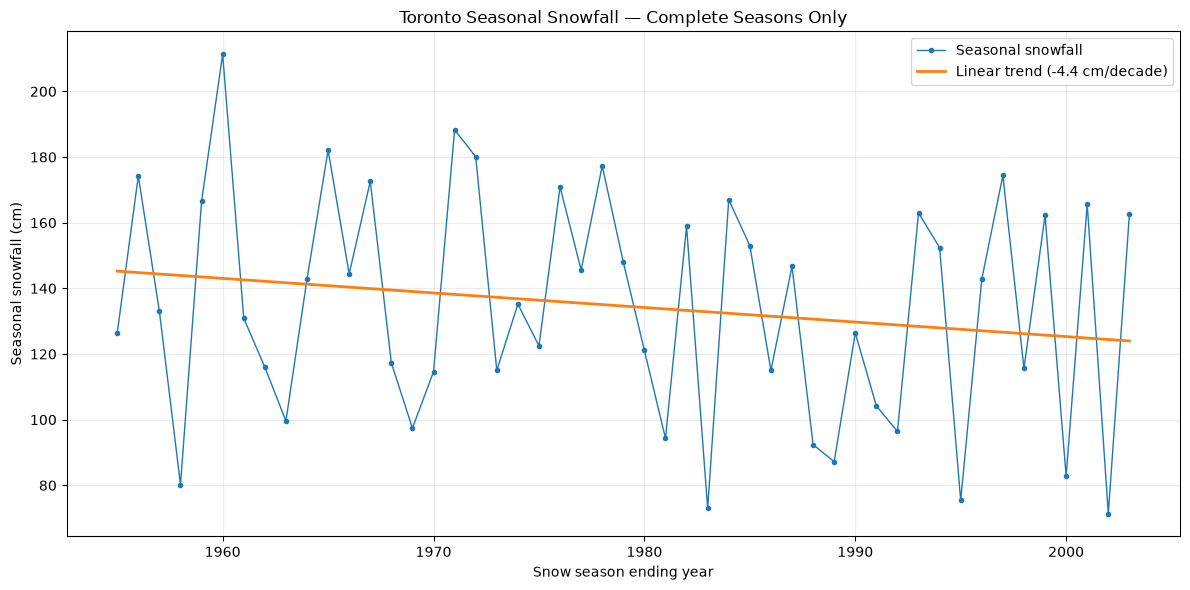

In [15]:

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    snow_trend["season_year"],
    snow_trend["snowfall_cm"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Seasonal snowfall"
)

ax.plot(
    snow_trend["season_year"],
    snow_result.intercept + snow_result.slope * snow_trend["season_year"],
    linewidth=2,
    label=f"Linear trend ({snow_result.slope*10:+.1f} cm/decade)"
)

ax.set_title("Toronto Seasonal Snowfall — Complete Seasons Only")
ax.set_xlabel("Snow season ending year")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "final_05_seasonal_snowfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 8. Final results table

In [16]:

results_summary = pd.DataFrame([
    {
        "metric": "Annual mean temperature",
        "period": "1954–2023",
        "trend": mean_result.slope * 10,
        "unit": "°C/decade",
        "p_value": mean_result.pvalue,
        "r2": mean_result.rvalue ** 2
    },
    {
        "metric": "Extreme hot days",
        "period": "1954–2023",
        "trend": hot_result.slope * 10,
        "unit": "days/decade",
        "p_value": hot_result.pvalue,
        "r2": hot_result.rvalue ** 2
    },
    {
        "metric": "Extreme cold days",
        "period": "1954–2023",
        "trend": cold_result.slope * 10,
        "unit": "days/decade",
        "p_value": cold_result.pvalue,
        "r2": cold_result.rvalue ** 2
    },
    {
        "metric": "Annual precipitation",
        "period": "1954–2023",
        "trend": precip_result.slope * 10,
        "unit": "mm/decade",
        "p_value": precip_result.pvalue,
        "r2": precip_result.rvalue ** 2
    },
    {
        "metric": "Seasonal snowfall",
        "period": f"{int(snow_trend['season_year'].min()-1)}–{int(snow_trend['season_year'].max())}",
        "trend": snow_result.slope * 10,
        "unit": "cm/decade",
        "p_value": snow_result.pvalue,
        "r2": snow_result.rvalue ** 2
    }
])

results_summary["significant_5pct"] = results_summary["p_value"] < 0.05

display(
    results_summary.style.format({
        "trend": "{:.3f}",
        "p_value": "{:.4f}",
        "r2": "{:.3f}"
    })
)

results_summary.to_csv(
    PROCESSED_DIR / "part_a_final_results.csv",
    index=False
)


,metric,period,trend,unit,p_value,r2,significant_5pct
0,Annual mean temperature,1954–2023,0.218,°C/decade,0.0000,0.290,True
1,Extreme hot days,1954–2023,1.355,days/decade,0.0160,0.082,True
2,Extreme cold days,1954–2023,-1.327,days/decade,0.0131,0.087,True
3,Annual precipitation,1954–2023,-8.919,mm/decade,0.2092,0.023,False
4,Seasonal snowfall,1954–2003,-4.432,cm/decade,0.2117,0.033,False


# 9. Decade comparison

In [17]:

first_decade = annual_temp[
    annual_temp["year"].between(1954, 1963)
]["annual_mean_temp"].mean()

recent_decade = annual_temp[
    annual_temp["year"].between(2014, 2023)
]["annual_mean_temp"].mean()

print(f"1954–1963 average temperature: {first_decade:.2f} °C")
print(f"2014–2023 average temperature: {recent_decade:.2f} °C")
print(f"Difference: {recent_decade-first_decade:+.2f} °C")

print("\nWarmest years:")
display(
    annual_temp.nlargest(5, "annual_mean_temp")[
        ["year", "annual_mean_temp"]
    ]
)

print("Coldest years:")
display(
    annual_temp.nsmallest(5, "annual_mean_temp")[
        ["year", "annual_mean_temp"]
    ]
)


1954–1963 average temperature: 8.08 °C
2014–2023 average temperature: 9.18 °C
Difference: +1.09 °C

Warmest years:


,year,annual_mean_temp
59,2012,10.590710
45,1998,10.274795
70,2023,10.269061
68,2021,10.253782
63,2016,10.177596


Coldest years:


,year,annual_mean_temp
23,1976,6.883607
19,1972,7.463388
61,2014,7.545455
12,1965,7.576712
43,1996,7.597253


# 10. Final conclusions

In [18]:

print("PART A — FINAL CLIMATE STORY")
print("-" * 70)

print(
    f"1. Toronto warmed by approximately {mean_result.slope*10:.2f} °C per decade "
    f"from 1954–2023 (p={mean_result.pvalue:.3g})."
)

winter_row = season_trends.loc[season_trends["season"] == "Winter"].iloc[0]
fall_row = season_trends.loc[season_trends["season"] == "Fall"].iloc[0]

print(
    f"2. Winter had the largest estimated seasonal warming rate "
    f"({winter_row['trend_c_per_decade']:.2f} °C/decade), while fall had the smallest "
    f"({fall_row['trend_c_per_decade']:.2f} °C/decade). "
    "These are separate trend estimates, not a formal test that one season warmed faster than another."
)

print(
    f"3. Relative to the fixed 1991–2020 temperature distribution, extreme hot days "
    f"increased by about {hot_result.slope*10:.2f} days per decade "
    f"(p={hot_result.pvalue:.3f}), while extreme cold days decreased by about "
    f"{abs(cold_result.slope*10):.2f} days per decade (p={cold_result.pvalue:.3f})."
)

print(
    f"4. Annual precipitation had an estimated trend of "
    f"{precip_result.slope*10:+.1f} mm per decade, but it was not statistically significant "
    f"(p={precip_result.pvalue:.3f})."
)

print(
    f"5. Seasonal snowfall across complete usable seasons had an estimated trend of "
    f"{snow_result.slope*10:+.1f} cm per decade, also not statistically significant "
    f"(p={snow_result.pvalue:.3f})."
)

print(
    f"6. The best segmented-regression breakpoint candidate was "
    f"{int(best_break['break_year'])}, but the slope-change test had "
    f"p={best_break['slope_change_p']:.3f}; therefore the analysis does not provide "
    "5%-level evidence of a statistically significant acceleration in warming."
)

print(
    f"7. The 2014–2023 decade was approximately "
    f"{recent_decade-first_decade:+.2f} °C warmer than 1954–1963."
)


PART A — FINAL CLIMATE STORY
----------------------------------------------------------------------
1. Toronto warmed by approximately 0.22 °C per decade from 1954–2023 (p=1.52e-06).
2. Winter had the largest estimated seasonal warming rate (0.33 °C/decade), while fall had the smallest (0.14 °C/decade). These are separate trend estimates, not a formal test that one season warmed faster than another.
3. Relative to the fixed 1991–2020 temperature distribution, extreme hot days increased by about 1.36 days per decade (p=0.016), while extreme cold days decreased by about 1.33 days per decade (p=0.013).
4. Annual precipitation had an estimated trend of -8.9 mm per decade, but it was not statistically significant (p=0.209).
5. Seasonal snowfall across complete usable seasons had an estimated trend of -4.4 cm per decade, also not statistically significant (p=0.212).
6. The best segmented-regression breakpoint candidate was 1976, but the slope-change test had p=0.077; therefore the analysis d

11. Limitations
- This is a single-location Toronto climate analysis, not a causal attribution study for global or regional climate change.
- The AHCCD temperature product adjusts important non-climatic discontinuities, but local influences such as urbanization and the urban heat island can still affect a city-centre record.
- Seasonal trend estimates are reported separately; differences between seasonal slopes were not formally tested.
- The segmented-regression breakpoint search is exploratory and tests multiple candidate years. The lowest-AIC breakpoint should not be interpreted as proof of a physical regime shift.
- Annual precipitation is highly variable from year to year; the fitted linear trend explains only a small fraction of that variability.
- The snowfall series becomes substantially incomplete after the 2002–03 snow season. Later incomplete seasons are excluded rather than treating missing days as zero snowfall.
- The snowfall product and temperature product are different ECCC datasets with different adjustment methodologies.
- Linear trends summarize average long-run direction and do not capture all nonlinear, decadal, or event-scale variability.

# 12. Save final analytical tables

In [20]:

annual_temp.to_csv(
    PROCESSED_DIR / "final_annual_temperature.csv",
    index=False
)

season_trends.to_csv(
    PROCESSED_DIR / "final_seasonal_temperature_trends.csv",
    index=False
)

extreme_counts.to_csv(
    PROCESSED_DIR / "final_temperature_extremes.csv",
    index=False
)

annual_precip.to_csv(
    PROCESSED_DIR / "final_annual_precipitation.csv",
    index=False
)

seasonal_snow.to_csv(
    PROCESSED_DIR / "final_seasonal_snowfall.csv",
    index=False
)

break_scan.to_csv(
    PROCESSED_DIR / "final_breakpoint_scan.csv",
    index=False
)

print("Saved final processed tables to:", PROCESSED_DIR)
print("Saved final figures to:", FIGURES_DIR)


Saved final processed tables to: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed
Saved final figures to: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/figures
